
# Taller — Titanic (Regresión Logística) con Pipeline + ColumnTransformer (ESQUELETO)

En esta tarea vas a **completar** un flujo profesional de clasificación para predecir `Survived`.

Tendrás tres archivos (en `data/`):
- `titanic_train_70.csv` (con etiquetas)
- `titanic_public_test_with_labels_15.csv` (con etiquetas, para experimentar)
- `titanic_private_test_without_labels_15.csv` (sin etiquetas, para la entrega)

🎯 Objetivo:
- Entrenar y evaluar tu modelo usando **train** y **public test**
- Generar `submission.csv` para el **private test**

✅ Reglas:
- Todo el preprocesamiento debe ir en un **Pipeline**
- Debes usar **Regresión Logística** como modelo final
- No inventes variables mirando el target en el private test (no existe)


## 1. Importar librerías

In [40]:

import os
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

import matplotlib.pyplot as plt


## 2. Cargar datasets

In [41]:
DATA_DIR = "."

train_path = os.path.join(DATA_DIR, "titanic_train_70.csv")
public_path = os.path.join(DATA_DIR, "titanic_public_test_with_labels_15.csv")
private_path = os.path.join(DATA_DIR, "titanic_private_test_without_labels_15.csv")

for p in [train_path, public_path, private_path]:
    assert os.path.exists(p), f"No encuentro el archivo: {p}"

train_df = pd.read_csv(train_path)
public_df = pd.read_csv(public_path)
private_df = pd.read_csv(private_path)

train_df.shape, public_df.shape, private_df.shape


((623, 12), (134, 12), (134, 11))

In [42]:

train_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,749,0,1,"Marvin, Mr. Daniel Warner",male,19.0,1,0,113773,53.1000,D30,S
1,46,0,3,"Rogers, Mr. William John",male,NaN,0,0,S.C./A.4. 23567,8.0500,NaN,S
2,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
3,634,0,1,"Parr, Mr. William Henry Marsh",male,NaN,0,0,112052,0.0000,NaN,S
4,404,0,3,"Hakkarainen, Mr. Pekka Pietari",male,28.0,1,0,STON/O2. 3101279,15.8500,NaN,S



## 3. Entender las variables (¡antes de modelar!)

Titanic trae columnas típicas como:

- **PassengerId**: identificador (NO explica supervivencia por sí mismo). Suele usarse solo para el submission.
- **Name**: texto con nombre (puede contener títulos como *Mr, Mrs, Miss*).
- **Sex**: sexo (categórica).
- **Age**: edad (numérica, con faltantes).
- **SibSp / Parch**: familiares a bordo (numéricas).
- **Ticket**: identificador de ticket (alta cardinalidad, puede introducir ruido).
- **Fare**: tarifa (numérica).
- **Cabin**: cabina (muchos faltantes, texto).
- **Embarked**: puerto de embarque (categórica).

👉 Tu trabajo: **decidir qué variables ayudan** y cuáles estorban.

### Pistas (no son reglas absolutas)
- Identificadores puros suelen aportar poco: `PassengerId`, `Ticket`.
- Texto libre puede ser difícil: `Name` (a menos que extraigas una señal simple como el título).
- Muchísimos faltantes: `Cabin` (a veces se descarta o se transforma a “tiene cabina: sí/no”).


### 3.1 Revisión rápida de tipos y faltantes

In [43]:

# Tipos de datos
train_df.dtypes


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [44]:

# Porcentaje de valores faltantes por columna (train)
missing_pct = (train_df.isna().mean().sort_values(ascending=False) * 100).round(2)
missing_pct


Cabin          78.17
Age            19.10
Embarked        0.32
PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
dtype: float64


### 3.2 Distribución del target

En `train` y `public` existe `Survived`.  
Revisa si hay desbalance (no siempre es grave, pero importa para métricas).


In [45]:

TARGET = "Survived"
train_df[TARGET].value_counts(normalize=True).rename("train")


Survived
0    0.616372
1    0.383628
Name: train, dtype: float64

In [46]:

public_df[TARGET].value_counts(normalize=True).rename("public")


Survived
0    0.61194
1    0.38806
Name: public, dtype: float64


## 4. Selección de variables (TODO)

Aquí vas a crear una lista de columnas para **eliminar** o **conservar**.

✅ Lo mínimo recomendado:
- Mantener variables claras: `Sex`, `Age`, `Pclass`, `Fare`, `SibSp`, `Parch`, `Embarked`
- No usar `PassengerId` como predictor (pero lo necesitas para el submission)
- Decidir qué hacer con `Name`, `Ticket`, `Cabin`

### TODO
1) Define una lista `DROP_COLS` con columnas que NO usarás como features.  
2) Crea `X_train`, `y_train`, `X_public`, `y_public`, `X_private` aplicando ese filtro.

💡 Consejo: empieza simple (descarta `Name`, `Ticket`, `Cabin`) y luego experimenta.


In [47]:
# TODO (estudiante):
DROP_COLS = ["PassengerId", "Name", "Ticket", "Cabin"]

# Ejemplo (solo como idea, cámbialo):
# DROP_COLS = ["PassengerId", "Name", "Ticket", "Cabin"]

# DROP_COLS = None  

# TODO (estudiante): crea X/y para train y public, y X para private.
# Requisitos:
# - y_train = train_df[TARGET]
# - y_public = public_df[TARGET]
# - X_private NO tiene TARGET

TARGET = "Survived"

# Train
y_train = train_df[TARGET]
X_train = train_df.drop(columns=DROP_COLS + [TARGET])

# Public
y_public = public_df[TARGET]
X_public = public_df.drop(columns=DROP_COLS + [TARGET])

# Private (sin TARGET)
X_private = private_df.drop(columns=DROP_COLS)

# Verificación rápida
X_train.shape, y_train.shape, X_public.shape, y_public.shape, X_private.shape


((623, 7), (623,), (134, 7), (134,), (134, 7))


## 5. Preprocesamiento con ColumnTransformer (TODO)

Usa:
- Numéricas: imputación + (opcional) escalado
- Categóricas: imputación + OneHotEncoder

### TODO
1) Identifica `num_cols` y `cat_cols` a partir de `X_train`  
2) Construye:
- `numeric_preprocess`
- `categorical_preprocess`
- `preprocess = ColumnTransformer(...)`


In [48]:
# TODO (estudiante):

# Identificar columnas numéricas y categóricas
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()


# Pipeline para variables numéricas
numeric_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   # imputar Age con mediana
    ("scaler", StandardScaler())                     # escalar variables
])


# Pipeline para variables categóricas
categorical_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  # imputar Embarked
    ("onehot", OneHotEncoder(handle_unknown="ignore"))     # one-hot encoding
])


# ColumnTransformer final
preprocess = ColumnTransformer(transformers=[
    ("num", numeric_preprocess, num_cols),
    ("cat", categorical_preprocess, cat_cols)
])


num_cols, cat_cols


(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], ['Sex', 'Embarked'])


## 6. Pipeline + Regresión Logística (TODO)

Crea un `Pipeline` con:
1) `("preprocess", preprocess)`
2) `("model", LogisticRegression(...))`

### TODO
- Crea `pipe`
- Entrena con `pipe.fit(X_train, y_train)`


In [49]:
# TODO (estudiante):

# Definir modelo
model = LogisticRegression(max_iter=1000)

# Crear pipeline completo
pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

# Entrenar
pipe.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True



## 7. Evaluación en el Public Test (TODO)

Calcula:
- `classification_report`
- matriz de confusión
- (opcional) ROC-AUC si usas `predict_proba`

### TODO
- Genera `y_pred_public`
- Muestra métricas


              precision    recall  f1-score   support

           0     0.8621    0.9146    0.8876        82
           1     0.8511    0.7692    0.8081        52

    accuracy                         0.8582       134
   macro avg     0.8566    0.8419    0.8478       134
weighted avg     0.8578    0.8582    0.8567       134



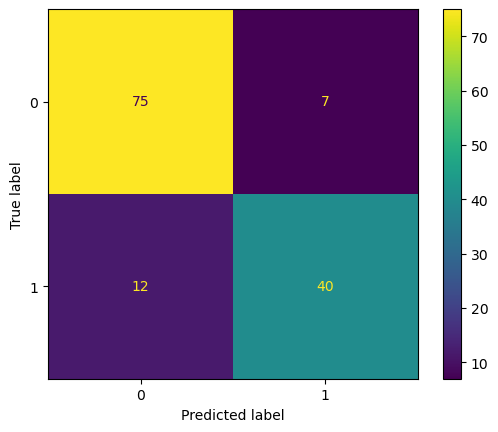

ROC-AUC: 0.8923545966228893


In [50]:
# TODO (estudiante):

# Predicciones en public
y_pred_public = pipe.predict(X_public)

# Reporte de clasificación
print(classification_report(y_public, y_pred_public, digits=4))

# Matriz de confusión
cm = confusion_matrix(y_public, y_pred_public)
ConfusionMatrixDisplay(cm).plot()
plt.show()

# ROC-AUC 
if hasattr(pipe, "predict_proba"):
    y_proba_public = pipe.predict_proba(X_public)[:, 1]
    print("ROC-AUC:", roc_auc_score(y_public, y_proba_public))



## 8. Entrenamiento final y submission (TODO)

Cuando decidas tu “mejor versión” del pipeline:

1) (Opcional) Entrena con **train + public** para tener más datos etiquetados.  
2) Predice el **private test sin etiquetas**.  
3) Genera `data/submission.csv` con:
- `PassengerId`
- `Survived` (predicción)

### TODO
- Entrenar final
- Predecir
- Guardar submission


In [51]:
# TODO (estudiante):

# 1) Unir train + public
full_train_df = pd.concat([train_df, public_df], axis=0, ignore_index=True)

# 2) Separar X e y
X_full = full_train_df.drop(columns=DROP_COLS + [TARGET])
y_full = full_train_df[TARGET]

# 3) Re-entrenar el pipeline con todos los datos etiquetados
pipe.fit(X_full, y_full)

# 4) Predecir sobre el private test
X_private_final = private_df.drop(columns=DROP_COLS)
private_pred = pipe.predict(X_private_final)

# 5) Crear submission
ID_COL = "PassengerId"
assert ID_COL in private_df.columns, "PassengerId debe existir en el private test"

submission = pd.DataFrame({
    ID_COL: private_df[ID_COL].values,
    TARGET: private_pred
})

# 6) Guardar archivo
out_path = os.path.join(DATA_DIR, "submission.csv")
submission.to_csv(out_path, index=False)

out_path


'./submission.csv'

In [52]:
submission.head()

,PassengerId,Survived
0,456,0
1,608,1
2,143,1
3,884,0
4,836,1



## 9. Ejercicios (elige al menos 3) — explica con evidencia

Usa métricas del **public test** para justificar tus respuestas (no solo opinión).

1) **Variables**: prueba incluir/excluir `Cabin`, `Name`, `Ticket`. ¿Qué cambia? ¿Por qué crees?
2) **Cabin simple**: crea una variable `HasCabin = Cabin.notna().astype(int)` y elimina `Cabin` original. ¿Mejora?
3) **Título del nombre**: extrae el título (Mr/Mrs/Miss/… ) desde `Name` y úsalo como categórica. ¿Mejora?
4) **Regularización**: prueba `C = 0.1, 1, 10`. ¿Qué pasa con precision/recall?
5) **Balanceo**: prueba `class_weight="balanced"`. ¿Mejora recall? ¿Pierde precisión?
6) **Escalado**: elimina `StandardScaler`. ¿Qué ocurre en regresión logística?

Plantilla para cada ejercicio:
- Cambio:
- Métricas (public):
- Explicación (2–5 líneas):
